In [3]:
%matplotlib inline

In [4]:
import json
import os

import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
from tqdm import tqdm

sns.set_context("notebook")
sns.set_style("whitegrid")

In [5]:
from inspect_ai.log import read_eval_log, ToolEvent

In [6]:
# eval_log = read_eval_log("logs/ReAct_GPT5_paper-finder-test.eval")
eval_log = read_eval_log(
    "../../agent-baselines/logs/gpt5_react_test_gpt-5_reasoning-effortmedium_paperfinder_updated_task_desc_4/2025-09-10T20-33-24+03-00_paper-finder-test_LTfFf9SjB9NxaqFzDHepiY.eval"
)

### Cost

In [7]:
eval_log.stats

EvalStats(started_at='2025-09-10T20:33:24+03:00', completed_at='2025-09-11T02:42:33+03:00', model_usage={'openai/gpt-5-2025-08-07': ModelUsage(input_tokens=267019401, output_tokens=5481789, total_tokens=272501190, input_tokens_cache_write=None, input_tokens_cache_read=51260544, reasoning_tokens=4002304), 'openai/gpt-4o-2024-11-20': ModelUsage(input_tokens=3224223, output_tokens=882953, total_tokens=4107176, input_tokens_cache_write=None, input_tokens_cache_read=0, reasoning_tokens=0)})

In [8]:
gpt5_usage = eval_log.stats.model_usage["openai/gpt-5-2025-08-07"]
cost = (
    ((gpt5_usage.input_tokens - gpt5_usage.input_tokens_cache_read) / 1_000_000) * 1.25
    + (gpt5_usage.input_tokens_cache_read / 1_000_000) * 0.125
    + (gpt5_usage.output_tokens / 1_000_000) * 10
)
cost_per_sample = cost / len(eval_log.samples)
print(f"Total cost: ${cost:.2f}, cost per sample: ${cost_per_sample:.4f}")

Total cost: $330.92, cost per sample: $1.2441


In [64]:
sum([len(s.error_retries) for s in eval_log.samples])

35

In [9]:
import re
from collections import Counter, defaultdict

def parse_eval_log(eval_log):
    tool_calls = []
    for sample in eval_log.samples:
        query = sample.metadata.get("raw_query")
        score_type = sample.metadata.get("score_type")
        sample_id = sample.id
        # if score_type == "specific_f1":
        #     print(sample.scores["score_paper_finder"].metadata)
        valid_corpusids_and_dates_list = sample.scores["score_paper_finder"].metadata.get(
            "valid_corpusids_and_dates"
        ) if "score_paper_finder" in sample.scores else None
        valid_corpusids_and_dates = sample.scores["score_paper_finder"].metadata[
            "valid_corpusids_and_dates_count"
        ] if "score_paper_finder" in sample.scores else None
        valid_corpusids_not_dates = sample.scores["score_paper_finder"].metadata[
            "valid_corpusids_not_dates_count"
        ] if "score_paper_finder" in sample.scores else None
        invalid_corpusids = sample.scores["score_paper_finder"].metadata[
            "invalid_corpusids_count"
        ] if "score_paper_finder" in sample.scores else None

        sample_tool_calls = []
        for event in sample.events:
            if isinstance(event, ToolEvent):
                sample_tool_calls.append(
                    {
                        "function": event.function,
                        "arguments": event.arguments,
                        "result": event.result,
                        "error": event.error,
                    }
                )
        tool_calls.append(
            {
                "sample_id": sample_id,
                "query": query,
                "score_type": score_type,
                "score": sample.scores["score_paper_finder"].value if "score_paper_finder" in sample.scores else None,
                "calls": sample_tool_calls,
                "valid_corpusids_and_dates_list": valid_corpusids_and_dates_list,
                "valid_corpusids_and_dates": valid_corpusids_and_dates,
                "valid_corpusids_not_dates": valid_corpusids_not_dates,
                "invalid_corpusids": invalid_corpusids,
            }
        )

    funcs_used = []
    funcs_ordered = []
    tool_call_args = defaultdict(list)
    for q in tool_calls:
        if "semantic" in q["score_type"]:
            #print(f"Query: {q['query']}")
            #print(f"Score Type: {q['score_type']}")
            
            query_funcs_used = []
            for call in q["calls"]:
                func_name = call["function"]
                if func_name == "snippet_search" and call["arguments"] and call["arguments"].get("paper_ids"):
                    func_name += "_with_paper_ids"
                query_funcs_used.append(func_name)
                args = call["arguments"]
                args["__result"] = call["result"]
                args["__error"] = call["error"]
                args["__query"] = q["query"]
                tool_call_args[func_name].append(args)
            funcs_ordered.append(query_funcs_used)
            functions = Counter(query_funcs_used)
            funcs_used.append(functions)
            #print(f"Functions: {functions}")

    # create a dataframe from each tool call argument
    arg_dfs = {function: pd.DataFrame(args) for function, args in tool_call_args.items()}
    func_df = pd.DataFrame(funcs_used)

    query_corpus_ids_submitted = []
    for call in tool_calls:
        valid_corpusids_and_dates_list = call.get("valid_corpusids_and_dates_list")
        valid_corpusids_and_dates = call["valid_corpusids_and_dates"]
        valid_corpusids_not_dates = call["valid_corpusids_not_dates"]
        invalid_corpusids = call["invalid_corpusids"]
        total_corpusids = (
            (valid_corpusids_and_dates or 0)
            + (valid_corpusids_not_dates or 0)
            + (invalid_corpusids or 0)
        )
        query_corpus_ids_submitted.append(
            {
                "sample_id": call["sample_id"],
                "query": call["query"],
                "score_type": call["score_type"],
                "valid_corpusids_and_dates_list": valid_corpusids_and_dates_list,
                "valid_corpusids_and_dates": valid_corpusids_and_dates,
                "valid_corpusids_not_dates": valid_corpusids_not_dates,
                "invalid_corpusids": invalid_corpusids,
                "total_corpusids": total_corpusids,
                "score": call["score"],
            }
        )

    scores_df = pd.DataFrame(query_corpus_ids_submitted)
    return tool_calls, arg_dfs, func_df, funcs_ordered, scores_df

tool_calls, arg_dfs, func_df, funcs_ordered, scores_df = parse_eval_log(eval_log)
func_df.fillna(0).describe()

,search_papers_by_relevance,snippet_search_with_paper_ids,search_paper_by_title,snippet_search,submit,get_paper_batch,get_paper
count,194.000000,194.000000,194.000000,194.000000,194.000000,194.000000,194.000000
mean,10.386598,1.474227,0.979381,2.154639,0.989691,0.067010,0.432990
std,6.891462,4.808440,2.632910,2.869674,0.101271,0.306483,1.409863
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,5.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
50%,8.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000
75%,13.750000,0.000000,1.000000,3.000000,1.000000,0.000000,0.000000
max,43.000000,33.000000,23.000000,18.000000,1.000000,2.000000,10.000000


In [10]:
len([c for c in tool_calls if "semantic" in c["score_type"]])

194

### How many does it submit?

In [11]:
# how many valid / invalid corpusids are submitted


scores_df.groupby("score_type").total_corpusids.describe().T

score_type,metadata_f1,semantic_f1,specific_f1
count,34.000000,194.000000,38.000000
mean,6.764706,23.592784,3.052632
std,8.224350,15.836082,5.331940
min,0.000000,0.000000,1.000000
25%,1.000000,13.000000,1.000000
50%,5.000000,21.000000,1.000000
75%,8.000000,30.750000,1.000000
max,39.000000,91.000000,25.000000


In [12]:

scores_df.groupby("score_type").score.describe().T

score_type,metadata_f1,semantic_f1,specific_f1
count,33.000000,194.000000,38.000000
mean,0.430407,0.152041,0.806198
std,0.361992,0.127200,0.352313
min,0.000000,0.000000,0.000000
25%,0.052632,0.056334,0.750000
50%,0.379310,0.128457,1.000000
75%,0.820513,0.222422,1.000000
max,1.000000,0.716256,1.000000


In [13]:
print("Weighted average:", scores_df.score.mean())
print("Macro average:", scores_df.groupby("score_type").score.mean().mean())

Weighted average: 0.28050913425732754
Macro average: 0.46288207485523575


In [14]:
(194*18.1 + 33*43.04 + 38*80.62) / (194 + 33 + 38)

30.170867924528306

<Axes: xlabel='total_corpusids', ylabel='score'>

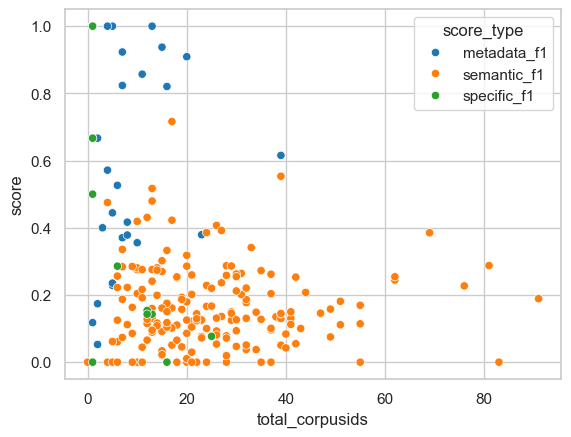

In [15]:
sns.scatterplot(data=scores_df, x="total_corpusids", y="score", hue="score_type")

In [16]:
scores_df[scores_df.score < 0.01]

,sample_id,query,score_type,valid_corpusids_and_dates_list,valid_corpusids_and_dates,valid_corpusids_not_dates,invalid_corpusids,total_corpusids,score
10,metadata_20,Papers from ASE 2017 or ICSE 2018 with at leas...,metadata_f1,[],0.0,0.0,1.0,1,0.0
13,metadata_23,"NeurIPS papers after 2023 that cite the ""RoBER...",metadata_f1,[],0.0,0.0,0.0,0,0.0
20,metadata_32,"ECOOP papers after 2018, not including, with a...",metadata_f1,[],0.0,0.0,0.0,0,0.0
27,metadata_41,"NeurIPS papers 2022-2023 that cite the ""RoBERT...",metadata_f1,[],0.0,0.0,0.0,0,0.0
28,metadata_43,"NeurIPS papers 2022-2023 that cite the ""RoBERT...",metadata_f1,[],0.0,0.0,0.0,0,0.0
29,metadata_44,Papers by Furu Wei that cite the RoBERTa paper,metadata_f1,[],0.0,0.0,1.0,1,0.0
30,metadata_45,papers citing the T5 paper and the spider pape...,metadata_f1,[],0.0,0.0,0.0,0,0.0
33,metadata_8,PADL 2012 with 20 citations or more,metadata_f1,[],0.0,0.0,0.0,0,0.0
35,semantic_10,Which papers explore the online adaptation of ...,semantic_f1,[259370785],1.0,0.0,0.0,1,0.0
49,semantic_118,AI2 dataset from around 2020 for reading compr...,semantic_f1,[222208714],1.0,0.0,0.0,1,0.0


### What tools are used? 

In [17]:
func_df

,search_papers_by_relevance,snippet_search_with_paper_ids,search_paper_by_title,snippet_search,submit,get_paper_batch,get_paper
0,8.0,12.0,1.0,2.0,1.0,NaN,NaN
1,5.0,NaN,NaN,3.0,1.0,NaN,NaN
2,8.0,NaN,1.0,4.0,1.0,2.0,NaN
3,7.0,NaN,NaN,2.0,1.0,NaN,NaN
4,13.0,NaN,NaN,NaN,1.0,NaN,NaN
...,...,...,...,...,...,...,...
189,12.0,NaN,NaN,NaN,1.0,NaN,NaN
190,20.0,NaN,7.0,2.0,1.0,NaN,8.0
191,9.0,22.0,1.0,1.0,1.0,NaN,NaN
192,13.0,2.0,NaN,3.0,1.0,NaN,9.0


In [18]:
func_df.describe()

,search_papers_by_relevance,snippet_search_with_paper_ids,search_paper_by_title,snippet_search,submit,get_paper_batch,get_paper
count,193.000000,40.000000,58.000000,117.000000,192.0,10.000000,35.000000
mean,10.440415,7.150000,3.275862,3.572650,1.0,1.300000,2.400000
std,6.868393,8.532141,3.977097,2.931153,0.0,0.483046,2.534468
min,1.000000,1.000000,1.000000,1.000000,1.0,1.000000,1.000000
25%,5.000000,1.000000,1.000000,2.000000,1.0,1.000000,1.000000
50%,8.000000,3.000000,1.000000,3.000000,1.0,1.000000,1.000000
75%,14.000000,9.750000,4.000000,4.000000,1.0,1.750000,2.000000
max,43.000000,33.000000,23.000000,18.000000,1.0,2.000000,10.000000


In [19]:
func_df.fillna(0).describe()

,search_papers_by_relevance,snippet_search_with_paper_ids,search_paper_by_title,snippet_search,submit,get_paper_batch,get_paper
count,194.000000,194.000000,194.000000,194.000000,194.000000,194.000000,194.000000
mean,10.386598,1.474227,0.979381,2.154639,0.989691,0.067010,0.432990
std,6.891462,4.808440,2.632910,2.869674,0.101271,0.306483,1.409863
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,5.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
50%,8.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000
75%,13.750000,0.000000,1.000000,3.000000,1.000000,0.000000,0.000000
max,43.000000,33.000000,23.000000,18.000000,1.000000,2.000000,10.000000


#### Tool combinations

In [20]:
fmelt = func_df.unstack().reset_index()
fmelt.columns = ["func", "query_id", "calls"]
fmelt = fmelt[(fmelt["calls"] > 0) & (fmelt.func!="submit")]
fmelt.groupby("query_id").apply(lambda x: sorted(x.func.unique())).value_counts()

/var/folders/pb/qz788cr500s2lnlvh1pmd3ph0000gn/T/ipykernel_26911/412874708.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  fmelt.groupby("query_id").apply(lambda x: sorted(x.func.unique())).value_counts()


[search_papers_by_relevance, snippet_search]                                                                           50
[search_papers_by_relevance]                                                                                           50
[search_paper_by_title, search_papers_by_relevance, snippet_search]                                                    17
[get_paper, search_papers_by_relevance, snippet_search]                                                                12
[search_papers_by_relevance, snippet_search_with_paper_ids]                                                            10
[get_paper, search_paper_by_title, search_papers_by_relevance, snippet_search]                                          9
[search_paper_by_title, search_papers_by_relevance, snippet_search, snippet_search_with_paper_ids]                      8
[search_paper_by_title, search_papers_by_relevance]                                                                     7
[get_paper, search_paper

In [21]:
fmelt.groupby("func").query_id.nunique().sort_values(ascending=False)

func
search_papers_by_relevance       193
snippet_search                   117
search_paper_by_title             58
snippet_search_with_paper_ids     40
get_paper                         35
get_paper_batch                   10
Name: query_id, dtype: int64

#### Tool chains

In [22]:
funcs_without_repeats = []
for funcs in funcs_ordered:
    funcs_wr = []
    current = None
    for func in funcs:
        if func != "submit" and func != current:
            funcs_wr.append(func)
            current = func
    funcs_without_repeats.append(tuple(funcs_wr))

Counter(funcs_without_repeats).most_common()


[(('search_papers_by_relevance',), 50),
 (('search_papers_by_relevance', 'snippet_search'), 17),
 (('search_papers_by_relevance',
   'snippet_search',
   'search_papers_by_relevance',
   'snippet_search'),
  10),
 (('search_papers_by_relevance',
   'snippet_search',
   'search_papers_by_relevance'),
  10),
 (('search_papers_by_relevance', 'snippet_search_with_paper_ids'), 7),
 (('search_papers_by_relevance',
   'search_paper_by_title',
   'search_papers_by_relevance'),
  4),
 (('search_papers_by_relevance',
   'snippet_search',
   'search_papers_by_relevance',
   'snippet_search',
   'search_papers_by_relevance'),
  4),
 (('search_papers_by_relevance',
   'snippet_search',
   'search_papers_by_relevance',
   'snippet_search',
   'search_papers_by_relevance',
   'snippet_search'),
  4),
 (('search_papers_by_relevance',
   'snippet_search',
   'search_papers_by_relevance',
   'get_paper',
   'snippet_search'),
  3),
 (('search_papers_by_relevance',
   'snippet_search',
   'search_papers_

### Tool arguments

In [23]:
arg_dfs.keys()

dict_keys(['search_papers_by_relevance', 'snippet_search_with_paper_ids', 'search_paper_by_title', 'snippet_search', 'submit', 'get_paper_batch', 'get_paper'])

In [24]:
arg_dfs["snippet_search"].head()

,query,limit,__result,__error,__query,venues
0,MADAMIRA supports Modern Standard Arabic and E...,5.0,"[internal=None type='text' text='{\n ""data"": ...",None,Are there any tools or studies that have focus...,NaN
1,"""Yet Another Multi-Dialect Arabic Morphologica...",5.0,"[internal=None type='text' text='{\n ""data"": ...",None,Are there any tools or studies that have focus...,NaN
2,online adaptation of neural MT evaluation metr...,20.0,"[internal=None type='text' text='{\n ""data"": ...",None,Which papers explore the online adaptation of ...,NaN
3,"""test-time adaptation"" translation evaluation ...",20.0,"[internal=None type='text' text='{\n ""data"": ...",None,Which papers explore the online adaptation of ...,NaN
4,"""test-time adaptation"" machine translation eva...",50.0,"[internal=None type='text' text='{\n ""data"": ...",None,Which papers explore the online adaptation of ...,NaN


In [25]:
snippet_searches_on_specific_id = arg_dfs["snippet_search_with_paper_ids"].shape[0] / arg_dfs["snippet_search"].shape[0]
print(f'{snippet_searches_on_specific_id=:<.2f}')

snippet_searches_on_specific_id=0.68


In [26]:
arg_dfs["snippet_search_with_paper_ids"].limit.describe()

count    284.000000
mean       8.260563
std       12.981193
min        3.000000
25%        5.000000
50%        5.000000
75%        5.000000
max      100.000000
Name: limit, dtype: float64

In [27]:
arg_dfs["snippet_search"].limit.describe()

count    376.000000
mean      12.555851
std        7.924784
min        5.000000
25%        5.000000
50%       10.000000
75%       20.000000
max       60.000000
Name: limit, dtype: float64

In [28]:
arg_dfs["search_papers_by_relevance"].limit.describe()

count    1977.000000
mean       17.405159
std         7.187077
min         5.000000
25%        10.000000
50%        20.000000
75%        20.000000
max       100.000000
Name: limit, dtype: float64

In [29]:
arg_dfs["search_papers_by_relevance"].fields.apply(lambda x: x.split(",") if pd.notna(x) else []).explode().value_counts()

fields
title                       1112
abstract                    1112
corpusId                    1112
authors                     1112
year                        1112
venue                       1112
citationCount                924
influentialCitationCount     894
referenceCount               778
url                          520
tldr                          32
publicationDate                6
Name: count, dtype: int64

In [30]:
arg_dfs["get_paper_batch"].fields.apply(lambda x: x.split(",") if pd.notna(x) else []).explode().value_counts()

fields
title                       10
year                        10
venue                       10
abstract                     9
corpusId                     9
authors                      7
url                          4
citationCount                1
referenceCount               1
influentialCitationCount     1
Name: count, dtype: int64

In [31]:
arg_dfs["search_paper_by_title"]["found"] = arg_dfs["search_paper_by_title"]["__error"].isna()

print("Successful title searches ratio:", arg_dfs["search_paper_by_title"]["found"].sum() / arg_dfs["search_paper_by_title"].shape[0])

Successful title searches ratio: 0.7315789473684211


In [32]:
title_searches_by_query = arg_dfs["search_paper_by_title"].groupby(["__query", "found"]).size().unstack()
title_searches_by_query

found,False,True
__query,,
Are there any large-scale and open-source text simplification datasets dealing with long passages?,NaN,1.0
Are there any tools or studies that have focused on building a morphological analyzer specifically for handling multiple Arabic dialects?,NaN,1.0
Are there papers which propose a general data selection method based on information theory?,1.0,8.0
Can LLMs detect LLM-generated text in a zero-shot manner? Do they perform better than supervised fine-tuned small classification models? Provide related papers.,1.0,NaN
Can you give an example of how statistical bootstrapping is used in practice?,NaN,1.0
Can you point me to a paper that discussed transformer-based sentence embeddings?,10.0,13.0
Could you recommend a study that investigates the implementation of sparsity within attention mechanisms to enhance the performance of models processing extremely lengthy documents?,NaN,4.0
Could you recommend research that investigates applying conventional data augmentation methods such as removing words and truncating sequences to contrastive learning in NLP applications?,NaN,1.0
Could you suggest a study that explores data annotation paradigms that help assuage concerns in lack of annotator expertise when using crowdsourcing?,NaN,1.0


In [33]:
num_semantic_searches = len([c for c in tool_calls if "semantic" in c["score_type"]])
title_query_tries = title_searches_by_query.shape[0]
title_tries_query_ratio = title_query_tries / num_semantic_searches
title_query_successes = (title_searches_by_query[True] > 0).sum()
successful_title_searches_query_ratio = title_query_successes / num_semantic_searches
print(f"{title_tries_query_ratio=:<.2f} ({title_query_tries} / {num_semantic_searches})")
print(f"{successful_title_searches_query_ratio=:<.2f} ({title_query_successes} / {num_semantic_searches})")

title_tries_query_ratio=0.30 (58 / 194)
successful_title_searches_query_ratio=0.23 (44 / 194)


## Compare relevance judgements

In [34]:
with open("detailed_reference_paperfinder.json", "r") as f:
    reference_pf = json.load(f)
with open("detailed_reference_react_4_6d1be228c3b6a1ea1318e62a9a7805db4fee4dc0.json", "r") as f:
    reference_react_4 = json.load(f)
len(reference_pf), len(reference_react_4)

(244, 232)

In [35]:
judgement_map = {
    "perfectly_relevant_papers": 3,
    "highly_relevant_papers": 2,
    "somewhat_relevant_papers": 1,
    "not_relevant_papers": 0,
}
judgement_pairs = []
new_recalls = []
for q, react_judgements in reference_react_4.items():
    if q not in reference_pf:
        print(f"Query in ReAct 4 not in PaperFinder: {q}")
    else:
        pf_judgements = reference_pf[q]
        pf_perfects = {
            corpus_id
            for corpus_id, judgement in pf_judgements.items()
            if judgement == "perfectly_relevant_papers"
        }
        react_perfects = set()
        react_perfects_if_override_with_pf = set()
        react_perfects_missing_in_pf = set()
        for corpus_id, judgement in react_judgements.items():
            pf_judgement = (
                judgement_map[pf_judgements[corpus_id]]
                if corpus_id in pf_judgements
                else -1
            )
            react_judgement = judgement_map[judgement]
            judgement_pairs.append(
                (
                    pf_judgement,
                    react_judgement,
                )
            )
            if react_judgement == 3:
                react_perfects.add(corpus_id)
            if pf_judgement == 3:
                react_perfects_if_override_with_pf.add(corpus_id)
            if react_judgement == 3 and pf_judgement == -1:
                react_perfects_missing_in_pf.add(corpus_id)
        new_recalls.append({
            "query": q,
            "pf_perfects": len(pf_perfects),
            "react_perfects": len(react_perfects),
            "react_perfects_if_override_with_pf": len(
                react_perfects_if_override_with_pf
            ),
            "react_perfects_missing_in_pf": len(react_perfects_missing_in_pf),
            "recall": len(react_perfects) / len(pf_perfects)
            if len(pf_perfects) > 0
            else 0,
            "new_recall": len(react_perfects_if_override_with_pf) / len(pf_perfects)
            if len(pf_perfects) > 0
            else 0,
            "new_recall_with_missing": (
                len(react_perfects_if_override_with_pf) + len(react_perfects_missing_in_pf)
            )
            / len(pf_perfects)
            if len(pf_perfects) > 0
            else 0,
        })

jpdf = pd.DataFrame(judgement_pairs, columns=["paperfinder", "react_4"])
# color it with a pandas style heatmap
jpdf.value_counts().unstack().fillna(0).astype(int).style.background_gradient(
    cmap="Blues", axis=None
)

react_4,0,1,2,3
paperfinder,,,,
-1,133,751,767,706
0,31,28,8,2
1,25,430,126,58
2,5,177,582,105
3,3,129,379,1145


In [36]:
recalls_df = pd.DataFrame(new_recalls)
recalls_df.describe()

,pf_perfects,react_perfects,react_perfects_if_override_with_pf,react_perfects_missing_in_pf,recall,new_recall,new_recall_with_missing
count,232.000000,232.000000,232.000000,232.000000,232.000000,232.000000,232.000000
mean,58.810345,8.689655,7.137931,3.043103,0.188251,0.172758,0.223824
std,58.726074,10.291352,6.581354,6.209046,0.210869,0.153659,0.211925
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,13.750000,2.000000,2.000000,0.000000,0.063497,0.062153,0.093491
50%,39.000000,5.000000,5.000000,1.000000,0.132704,0.132843,0.190066
75%,90.250000,11.000000,10.000000,3.000000,0.241453,0.235498,0.295406
max,368.000000,64.000000,34.000000,48.000000,1.800000,0.875000,2.000000


In [37]:
22.382 / 18.8251

1.1889445474393232

In [38]:
15.2*1.189

18.0728

#### Compare to pf agent judgements

In [39]:
for q in query_corpus_ids_submitted:
    if "semantic" in q["score_type"]:
        print("'" + q["query"].replace("'", "''") + "',")

NameError: name 'query_corpus_ids_submitted' is not defined

In [40]:
# SELECT input_query, corpus_id, min(relevance) as min_relevance, max(relevance) as max_relevance, avg(relevance) as avg_relevance FROM cs_dev.result_set
# left join cs_dev.document_collection on cs_dev.document_collection.result_set_id = cs_dev.result_set.id
# left join cs_dev.document on cs_dev.document.doc_collection_id = cs_dev.document_collection.id
# left join cs_dev.relevance_judgement on cs_dev.relevance_judgement.document_id = cs_dev.document.id
# where input_query IN ('What are some of the key advantages and challenges of building multilingual evaluation datasets by translating existing English datasets into other target languages? Or more specifically, how do these translated datasets impact the quality and reliability of cross-lingual evaluations, and what potential pitfalls should be considered when using translations as a primary method for creating non-English benchmarks? ',
# 'Interdisciplinary research usually takes extra efforts to conduct. Are there any systems or approaches to facilitate interdisciplinary research and cross-domain discovery in scientific fields?',
# 'What are the common model architectures for retrieval-augmented language models?
# ',
# 'Has anyone tried fine tuning with RAG— or have seen work on this?',
# 'Pruning is a means of model compression that can improve model efficiency in NLP. What are some recent general, task-agnostic pruning methods for large language methods that have worked well?',
# 'Could you please provide some references to work on multi-document summarization?',
# 'Compare the performance and advantages of LSTMs versus basic RNNs (vanilla RNNs) on NLP tasks. What evidence shows that LSTMs perform better than basic RNNs, and what are the key reasons for any performance differences?',
# 'What are some pretraining techniques to improve language model reasoning abilities, especially focusing on pretraining with chain of thought?',
# 'What are the key references for super-resolution techniques used in measuring diameters in images?',
# 'Are language models better at discriminating among previously generated alternatives compared to generating initial responses? What evidence exists about their relative performance in generation vs discrimination tasks?',
# 'Has any work been done using large language models (LLMs) to generate blog posts from scientific papers? Please summarize the results.',
# 'papers studying LLMs'' abilities of generating new research ideas in NLP',
# 'earliest paper comparing two dialogue systems with win rates judged by humans',
# 'research on generative document retrieval models that allow for quick addition of new documents as they become available',
# 'State-of-the-art papers focusing on sampling mechanisms at LLM inference time, including mechanisms like majority voting and reward model scoring in the context of sample selection.',
# 'vision language models that use perceivers to encode images',
# 'What are the current solutions and approaches to address the transcription bottleneck in linguistic fieldwork and documentation of endangered languages? Include both technological and methodological solutions.',
# 'What are the central methods for aligning AI systems with human values?',
# 'papers about long term memory in agents',
# 'Are there generative retrieval methods that can handle new documents and add them to the trained retrieval model?',
# 'recent papers about large language models (LLMs) processing hypothetical conditional statements',
# 'papers discussing how modern language models set d_model and number of layers in transformer architecture, focusing on the effects of long narrow vs wide shallow models',
# 'What are some datasets for task-oriented grasping?',
# 'Adaptive query expansion with LLMs, focusing on papers published on or after 2023',
# 'papers on individually identifying individuals based on their word choice or other lexical features',
# 'Could you suggest research that investigates a clustering-based efficient attention mechanism within Transformer models?',
# 'Video aesthetics score, using multimodal large models.',
# 'Can you help me find research papers that explore the use of large vision-language models as agents to automatically play PC games?',
# 'Search for papers related to large language models that demonstrate how the same prompt with different responses can improve the performance of the SFT model.',
# 'Show me research on rejection sampling finetuning.',
# 'Which papers propose to mask positions to pre-train multi-modal document transformer？',
# 'What papers discuss the use of transformer architecture in 3d video generation',
# 'DPO training for large-scale vision-language models.',
# 'I am looking for research papers on the construction of multimodal foundation models that support both visual and audio inputs. These models should be pre-trained on large-scale datasets, including visual, audio, and audio-visual data. Please exclude survey papers.',
# 'List all papers that use autoregressive transformer to generate videos.',
# 'Show me research on the long video description. Here, long videos are defined as those with a duration of at least several minutes.',
# 'Is there any work that analyzes the scaling law of the multi-module models, such as video-text, image-text models?',
# 'Find papers on trigger-free document-level event extraction methods that do not use human-annotated triggers.',
# 'Could you suggest a study that explores employing a beta distribution to sample span sizes within unsupervised learning frameworks for text representation?',
# 'Could you direct me to research that evaluates few-shot slot tagging model performance by averaging micro-F1 scores across different test episodes?',
# 'Could you recommend a study that explores how language models are not robust to the surface form editing when testing commonsense knowledge?',
# 'What is the performance of large language models in text summarization under reference-based and reference-free human evaluations?',
# 'Have any research efforts been made to gather dialogue data via crowdworkers to enhance conversational information retrieval systems?',
# 'Could you recommend research that evaluates the performance decline in various language models, like BLOOM, under 4-bit integer columnar weight-only quantization?',
# 'What papers use decoupled workers in distributed RL system?',
# 'Could you recommend a study that investigates how contrastive learning enhances sentence-level embeddings in natural language processing, especially for subsequent applications?',
# 'Can you recommend some literature that focuses on dependency-based models for relation extraction, especially those that utilize dependency parsing to capture non-local syntactic relations?',
# 'How can complex word identification (CWI) models be personalized to improve their performance for individual users with different language backgrounds and proficiency levels?')
# and corpus_id is not null
# group by input_query, corpus_id
# order by avg_relevance DESC;

In [41]:
judgements_from_db = pd.read_csv("judgements_from_db_validation.csv")
judgements_from_db.head()

,input_query,corpus_id,min_relevance,max_relevance,avg_relevance
0,How can complex word identification (CWI) mode...,213066785,3,3,3.0
1,Could you recommend a study that explores how ...,270560449,3,3,3.0
2,Could you recommend a study that investigates ...,254853816,3,3,3.0
3,DPO training for large-scale vision-language m...,278959323,3,3,3.0
4,How can complex word identification (CWI) mode...,264987236,3,3,3.0


In [42]:
judgements_from_db[judgements_from_db.max_relevance == 3].input_query.value_counts()

input_query
What papers use decoupled workers in distributed RL system?                                                                                                                                                                                                                  174
What is the performance of large language models in text summarization under reference-based and reference-free human evaluations?                                                                                                                                           161
papers on individually identifying individuals based on their word choice or other lexical features                                                                                                                                                                          154
papers about long term memory in agents                                                                                                                                  

In [43]:
query_perfects = {}
total_submitted = {}
for q in query_corpus_ids_submitted:
    if "semantic" not in q["score_type"]:
        continue
    perfects_found = []
    for corpus_id in q["valid_corpusids_and_dates_list"]:
        try:
            int(corpus_id)
        except ValueError:
            continue
        match = judgements_from_db[(judgements_from_db["input_query"] == q["query"]) & (judgements_from_db['corpus_id'] == int(corpus_id))].max_relevance
        if not match.empty:
            if match.values[0] == 3:
                perfects_found.append(corpus_id)
    query_perfects[q["query"]] = perfects_found
    total_submitted[q["query"]] = len(q["valid_corpusids_and_dates_list"])

for q, perfects in query_perfects.items():
    num_perfects = len(perfects)
    print(f"Query: {q}\nPerfects found: {num_perfects} ({perfects})")
    perfects_in_db = judgements_from_db[(judgements_from_db['input_query'] == q) & (judgements_from_db['max_relevance'] == 3)].shape[0]
    print(f"Perfects in DB: {perfects_in_db}")
    print(f"Recall: {num_perfects}/{perfects_in_db} = {num_perfects/perfects_in_db if perfects_in_db > 0 else 0:.2f}")
    print(f"Total submitted: {total_submitted[q]}")
    print("Precision: ", end="")
    if num_perfects > 0:
        print(f"{num_perfects}/{total_submitted[q]} = {num_perfects/total_submitted[q]:.2f}\n")
    else:
        print("0.00\n")


NameError: name 'query_corpus_ids_submitted' is not defined

In [44]:
scores_df[scores_df.valid_corpusids_not_dates > 0].shape[0]

14

In [45]:
scores_df[scores_df.invalid_corpusids > 0]

,sample_id,query,score_type,valid_corpusids_and_dates_list,valid_corpusids_and_dates,valid_corpusids_not_dates,invalid_corpusids,total_corpusids,score
10,metadata_20,Papers from ASE 2017 or ICSE 2018 with at leas...,metadata_f1,[],0.0,0.0,1.0,1,0.000000
29,metadata_44,Papers by Furu Wei that cite the RoBERTa paper,metadata_f1,[],0.0,0.0,1.0,1,0.000000
99,semantic_177,Can hyperspectral imagery be useful for shallo...,semantic_f1,[],0.0,0.0,24.0,24,0.228353


## Compare to paper finder

In [51]:
eval_log_gpt5_orig = read_eval_log("logs/ReAct_GPT5_paper-finder-test.eval")
(
    tool_calls_gpt5_orig,
    arg_dfs_gpt5_orig,
    func_df_gpt5_orig,
    funcs_ordered_gpt5_orig,
    scores_df_gpt5_orig,
) = parse_eval_log(eval_log_gpt5_orig)
print(scores_df_gpt5_orig.score.mean())
scores_df_gpt5_orig.groupby("score_type").score.mean()

0.1779624919553419


score_type
metadata_f1    0.348100
semantic_f1    0.080293
specific_f1    0.519885
Name: score, dtype: float64

In [52]:
gpt5_usage = eval_log_gpt5_orig.stats.model_usage["openai/gpt-5-2025-08-07"]
cost = (
    ((gpt5_usage.input_tokens - gpt5_usage.input_tokens_cache_read) / 1_000_000) * 1.25
    + (gpt5_usage.input_tokens_cache_read / 1_000_000) * 0.125
    + (gpt5_usage.output_tokens / 1_000_000) * 10
)
cost_per_sample = cost / len(eval_log.samples)
print(f"Total cost: ${cost:.2f}, cost per sample: ${cost_per_sample:.4f}")

Total cost: $161.46, cost per sample: $0.6070


In [65]:
sum([len(s.error_retries) for s in eval_log_gpt5_orig.samples])

23

In [46]:
eval_log_pf = read_eval_log("logs/paper-finder_paper-finder-test.eval")
tool_calls_pf, arg_dfs_pf, func_df_pf, funcs_ordered_pf, scores_df_pf = parse_eval_log(eval_log_pf)


In [47]:
scores_df_pf.groupby("score_type").score.describe().T

score_type,metadata_f1,semantic_f1,specific_f1
count,35.000000,194.000000,38.000000
mean,0.641580,0.354807,0.388530
std,0.390943,0.144439,0.405569
min,0.000000,0.000000,0.000000
25%,0.285874,0.266960,0.000000
50%,0.800000,0.360978,0.214286
75%,1.000000,0.453421,0.666667
max,1.000000,0.676918,1.000000


In [48]:
scores_df_pf.groupby("score_type").score.mean()

score_type
metadata_f1    0.641580
semantic_f1    0.354807
specific_f1    0.388530
Name: score, dtype: float64

In [49]:
scores_df_pf.score.mean()

np.float64(0.397198076762731)

<Axes: xlabel='score_pf', ylabel='score_react'>

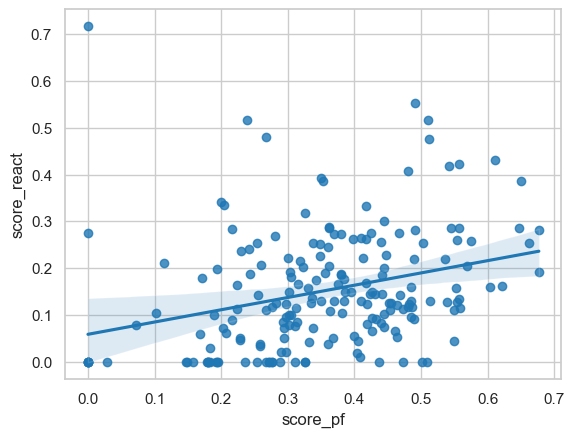

In [303]:
# compare scores_df and scores_df_pf
merged_scores = scores_df.merge(
    scores_df_pf[[c for c in scores_df_pf.columns if c not in ("score_type", "query")]],
    on="sample_id",
    suffixes=("_react", "_pf"),
)
sns.regplot(data=merged_scores[merged_scores["score_type"] == "semantic_f1"], x="score_pf", y="score_react")

In [307]:
merged_scores["score_diff"] = merged_scores["score_react"] - merged_scores["score_pf"]
merged_scores[
    (merged_scores["score_type"] == "semantic_f1")
    & (merged_scores["score_pf"] < merged_scores["score_react"])
][
    [
        "sample_id",
        "query",
        "score_pf",
        "score_react",
        "total_corpusids_pf",
        "total_corpusids_react",
        "score_diff",
    ]
].sort_values("score_diff", ascending=False).round(2)

,sample_id,query,score_pf,score_react,total_corpusids_pf,total_corpusids_react,score_diff
79,semantic_153,papers and datasets similar to DocBank or PubL...,0.00,0.72,0,17,0.72
195,semantic_63,In the field of reinforcement learning models ...,0.24,0.52,141,13,0.28
197,semantic_65,Which paper first apply mixture of experts ide...,0.00,0.28,358,11,0.28
185,semantic_53,Have any research papers examined whether usin...,0.27,0.48,249,13,0.21
162,semantic_30,What research should I explore to understand m...,0.20,0.34,87,33,0.14
80,semantic_154,papers that use large language models (LLM) wi...,0.20,0.34,379,7,0.13
179,semantic_48,What approaches have been used to address the ...,0.11,0.21,206,30,0.10
68,semantic_14,Is there a dialogue dataset where a speaker's ...,0.22,0.28,306,7,0.07
127,semantic_209,Show me all research papers on machine transla...,0.49,0.55,275,39,0.06
201,semantic_69,Could you recommend studies that concentrate o...,0.35,0.39,108,27,0.04
